In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from bayspecdec.spectrum_gen import *
import bayspecdec as bsd

from functools import partial

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
Array = np.ndarray[tuple[int], np.dtype(np.float32)]

In [4]:
BIN_SIZE: float = 1e-1
MIN: float = 0
MAX: float = 10

In [5]:
DET_AX: Array = np.arange(MIN, MAX, BIN_SIZE)
PEAK: Array = np.zeros_like(DET_AX)
PEAK += lorentzian(DET_AX, 5, 0.5, 1)

In [6]:
SIGNAL: Array = np.zeros_like(DET_AX)
SIGNAL[bin_idx(DET_AX, 1)] += 1
SIGNAL[bin_idx(DET_AX, 7)] += 2
SIGNAL[bin_idx(DET_AX, 4)] += 2
# SIGNAL[bin_idx(DET_AX, 6)] += 2

BLURRED: Array = sp.signal.convolve(SIGNAL, PEAK, mode="full")[
    len(DET_AX) // 2 : -len(DET_AX) // 2 + 1
]

y = np.random.normal(loc=BLURRED, scale=0.1)
# y = draw_spectrum(BLURRED, dose=100_000).astype(np.float64)
# y /= y.max()

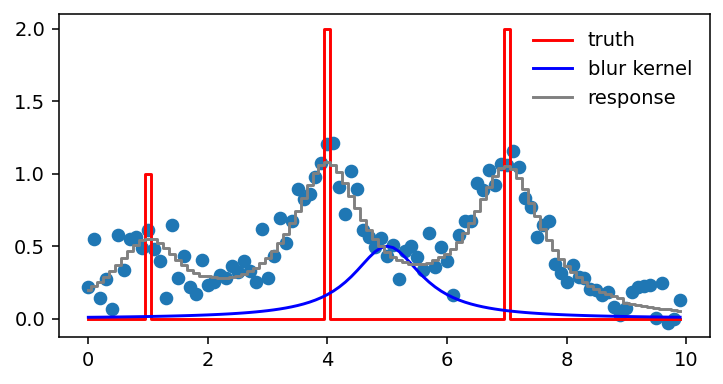

In [7]:
plt.step(DET_AX, SIGNAL, where="mid", label="truth", color="red")
plt.plot(DET_AX, PEAK, label="blur kernel", color="blue")
plt.step(DET_AX, BLURRED, where="mid", label="response", color="gray")
plt.scatter(DET_AX, y)
fig = plt.gcf()
fig.set_size_inches(6, 3)
fig.set_dpi(140)
plt.legend(frameon=False)

In [8]:
from typing import Iterable


class BlurKernel:
    name: str = "BlurKernel"
    n_parameters_per_basis: int = 1

    def evaluate(self, x: Array, params: Iterable[Array]) -> Array:
        (μ,) = params
        evals = []
        for μi in μ:
            peak = lorentzian(x, μi, 0.5, 1)
            peak /= peak.max()
            evals.append(peak)
        return np.stack(evals)

In [9]:
from numba.experimental.jitclass.decorators import jitclass


class Parameterization:
    def __init__(self, K: int):
        self.K = K
        self.ndim = 2 * K

    def pack(self, structured: tuple[Array, Array, Array]) -> Array:
        I, μ = structured
        θ = np.empty(self.ndim)
        θ[: self.K] = I
        θ[self.K : 2 * self.K] = μ
        # θ[2 * self.K :] = σ
        return θ

    def unpack(self, θ: Array) -> tuple[Array, Array, Array]:
        I: Array = θ[..., : self.K]
        μ: Array = θ[..., self.K : 2 * self.K]
        # σ: Array = θ[..., 2 * self.K :]
        return (I, μ)  # , σ)

    def to_z(self, θ: Array) -> Array:
        z = θ.copy()
        # z[..., : self.K] = np.log(z[..., : self.K])
        return z

    def from_z(self, z: Array) -> Array:
        θ = z.copy()
        # θ[..., : self.K] = np.exp(θ[..., : self.K])
        return θ

    def log_jacobian(self, θ: Array) -> float:
        return 1
        I, μ, σ = self.unpack(θ)
        return float(np.sum(np.log(I)) + np.sum(np.log(θ)))

In [10]:
class LorentzPrior:
    def __init__(self, amplitudes, centers):  # , widths):
        self.amplitudes = amplitudes
        self.centers = centers
        # self.widths = widths

    def sample(self, rng, parameterization) -> Array:
        K: int = parameterization.K
        I: Array = self.amplitudes.sample(rng, K)
        μ: Array = self.centers.sample(rng, K)
        # σ: Array = self.widths.sample(rng, K)
        # print(f"I: {I}, μ: {μ}, σ: {σ}")
        # for Ii, μi, σi in zip(I, μ, σ):
        #     plt.plot(lorentzian(DET_AX, μi, σi, Ii))
        # plt.show()
        return parameterization.pack((I, μ))

    def log_prob(self, θ, parameterization) -> float:
        I, μ = parameterization.unpack(θ)
        lp_I = np.sum(self.amplitudes.log_prob(I))
        lp_μ = np.sum(self.centers.log_prob(μ))
        # lp_σ = np.sum(self.widths.log_prob(σ))
        return float(lp_I + lp_μ)  # + lp_σ)

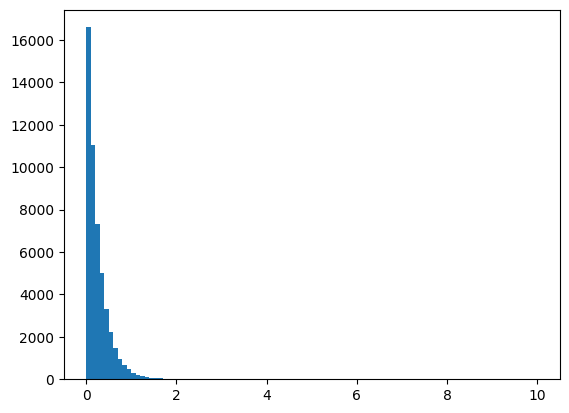

In [11]:
plt.hist(
    bsd.GammaPrior(1, 4).sample(np.random.default_rng(), 50_000),
    range=(0, 10),
    bins=100,
);

In [23]:
lorentz_prior = LorentzPrior(
    amplitudes=bsd.UniformPrior(0.2, 1.2),
    centers=bsd.UniformPrior(1, 9),
    # widths=bsd.GammaPrior(5, 8),
)

In [24]:
betas = bsd.beta_schedule(64)

In [25]:
def spectral_model_builder(K: int) -> bsd.SpectralModel:
    return bsd.SpectralModel(
        x=DET_AX,
        y=y,
        basis=BlurKernel(),
        prior=lorentz_prior,
        likelihood=bsd.GaussianNoise(sigma2=0.01),
        parameterization=Parameterization(K=K),
    )


def sampler_builder(model, rng):
    K = model.parameterization.K
    return bsd.ParallelTempering(
        model=model,
        betas=betas,
        rng=np.random.default_rng(),
        kernel_factory=partial(
            bsd.metropolis_kernel_factory,
            proposal_scales=np.repeat([0.01, 0.05], repeats=K),
        ),
        # kernel_factory=lambda model, beta, rng: bsd.hmc_kernel_factory(
        #     model, beta, rng
        # ),
    )

In [26]:
runs = bsd.select_model_size(
    model_factory=spectral_model_builder,
    K_values=[2, 3, 4],
    sampler_factory=sampler_builder,
    burn_in=1_000,
    samples=10_000,
    swap_every=1,
    # store_state_trace=True,
)

100%|███████████████████████████████████████████████████████████████| 10000/10000 [02:34<00:00, 64.90it/s]


K= 2 | stochastic complexity -log Z =  247.561 | beta=1 MH acc=0.266 | mean swap acc=0.909


100%|███████████████████████████████████████████████████████████████| 10000/10000 [02:57<00:00, 56.40it/s]


K= 3 | stochastic complexity -log Z =  111.020 | beta=1 MH acc=0.229 | mean swap acc=0.894


100%|███████████████████████████████████████████████████████████████| 10000/10000 [03:16<00:00, 50.78it/s]


K= 4 | stochastic complexity -log Z =  112.058 | beta=1 MH acc=0.228 | mean swap acc=0.890


In [27]:
evidence = [-r.evidence.log_z for r in runs]
best_run = np.argmin(evidence)
K_values = [r.K for r in runs]

optimal_K = K_values[best_run]
print(f"K: {optimal_K}, -logZ: {evidence[best_run]}")

K: 3, -logZ: 111.02014274627794


In [28]:
print(evidence)

[247.56099414268004, 111.02014274627794, 112.05841298550382]


In [29]:
posteriors = runs[best_run].exchange_result.samples_by_temperature[-1]

μ: 0.890±0.056;
μ: 3.982±0.026;
μ: 6.965±0.025;


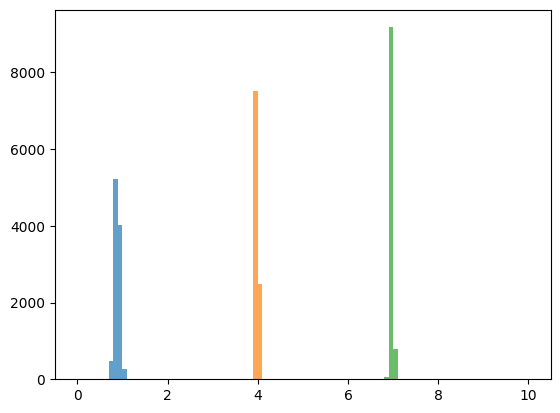

In [30]:
I, μ = Parameterization(K=optimal_K).unpack(
    runs[best_run].exchange_result.samples_by_temperature[-1]
)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, axis=1, indices=key)
μ = np.take_along_axis(μ, axis=1, indices=key)
# σ = np.take_along_axis(σ, axis=1, indices=key)

for i in range(optimal_K):
    plt.hist(μ[:, i], range=(0, 10), bins=100, alpha=0.7)
    print(
        f"μ: {np.nanmean(μ[:, i]):.3f}±{np.nanstd(μ[:, i]):.3f};"  # σ: {np.nanmean(σ[:, i]):.3f}±{np.nanstd(σ[:, i]):.2f}"
    )

center: 0.89, height: 0.45
center: 3.98, height: 1.03
center: 6.96, height: 1.01


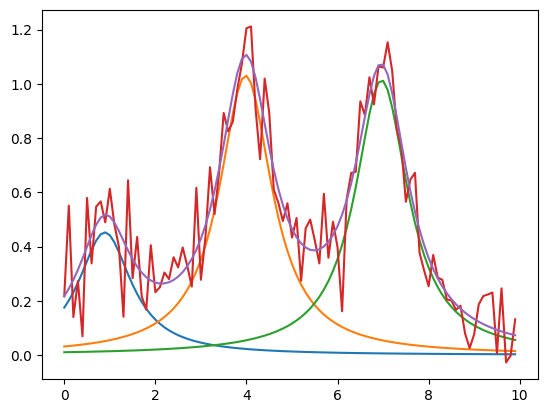

In [31]:
evals = []
for i in range(optimal_K):
    Ii = np.nanmean(I[:, i])
    μi = np.nanmean(μ[:, i])
    # σi = np.nanmean(σ[:, i])
    print(f"center: {μi:.2f}, height: {Ii:.2f}")
    trace = lorentzian(DET_AX, μi, 0.5, 1)
    trace /= trace.max()
    trace *= Ii
    evals.append(trace)
    plt.plot(DET_AX, trace)

plt.plot(DET_AX, y)
plt.plot(DET_AX, np.stack(evals).sum(axis=0))

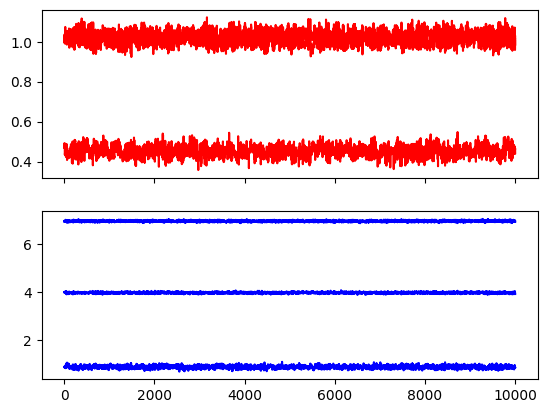

In [32]:
states = runs[best_run].exchange_result.samples_by_temperature[-1]
I, μ = Parameterization(K=optimal_K).unpack(states)
key = np.argsort(μ, axis=1)

I = np.take_along_axis(I, indices=key, axis=1)
μ = np.take_along_axis(μ, indices=key, axis=1)
# σ = np.take_along_axis(σ, indices=key, axis=1)

fig, (tax, bax) = plt.subplots(nrows=2, sharex=True)

tax.plot(
    I,
    label="amplitudes",
    color="red",
)
bax.plot(
    μ,
    label="centers",
    color="blue",
)